# Практическое задание №4

Используйте данные из файла **StudentPerformanceFactors.csv** с информацией о студентах.

[Источник](https://www.kaggle.com/datasets/lainguyn123/student-performance-factors/code)

В нём содержаться следующие переменные:


| Название переменной | Описание переменной
|:-------------------:|:------------------:|
| Hours_Studied | Number of hours spent studying per week |
| Attendance | Percentage of classes attended |
| Parental_Involvement | Level of parental involvement in the student's education (Low, Medium, High)|
| Access_to_Resources | Availability of educational resources (Low, Medium, High)|
| Extracurricular_Activities | Participation in extracurricular activities (Yes, No).
| Sleep_Hours | Average number of hours of sleep per night.
| Previous_Scores |	Scores from previous exams.
| Motivation_Level |	Student's level of motivation (Low, Medium, High).
| Internet_Access |	Availability of internet access (Yes, No).
| Tutoring_Sessions |	Number of tutoring sessions attended per month.
| Family_Income |	Family income level (Low, Medium, High).
| Teacher_Quality |	Quality of the teachers (Low, Medium, High).
| School_Type |	Type of school attended (Public, Private).
| Peer_Influence |	Influence of peers on academic performance (Positive, Neutral, Negative).
| Physical_Activity |	Average number of hours of physical activity per week.
| Learning_Disabilities |	Presence of learning disabilities (Yes, No).
| Parental_Education_Level |	Highest education level of parents (High School, College, Postgraduate).
| Distance_from_Home |	Distance from home to school (Near, Moderate, Far).
| Gender |	Gender of the student (Male, Female).
| Exam_Score |	Final exam score.

In [171]:
import matplotlib.pyplot as plt
import seaborn as sns

In [172]:
import pandas as pd
import numpy as np

df = pd.read_csv('StudentPerformanceFactors.csv')
df.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


In [173]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Hours_Studied               6607 non-null   int64 
 1   Attendance                  6607 non-null   int64 
 2   Parental_Involvement        6607 non-null   object
 3   Access_to_Resources         6607 non-null   object
 4   Extracurricular_Activities  6607 non-null   object
 5   Sleep_Hours                 6607 non-null   int64 
 6   Previous_Scores             6607 non-null   int64 
 7   Motivation_Level            6607 non-null   object
 8   Internet_Access             6607 non-null   object
 9   Tutoring_Sessions           6607 non-null   int64 
 10  Family_Income               6607 non-null   object
 11  Teacher_Quality             6529 non-null   object
 12  School_Type                 6607 non-null   object
 13  Peer_Influence              6607 non-null   obje

Выполните, пожалуйста, задания.

# 1. Используйте в качестве зависимой переменной при построении линейной регрессии переменную Exam_Score. Выберите не менее 3 категориальных и 3 метрических предикторов. Убедитесь, что не наблюдается высокой корреляции между метрическими предикторами, а категориальные предикторы не дублируют друг друга по значениям.

In [174]:
num_cols = ['Hours_Studied', 'Physical_Activity', 'Previous_Scores']
cat_cols = ['Gender', 'Parental_Education_Level', 'School_Type']

cols = num_cols + cat_cols + ['Exam_Score']
df = df[cols]
df.head()

,Hours_Studied,Physical_Activity,Previous_Scores,Gender,Parental_Education_Level,School_Type,Exam_Score
0,23,3,73,Male,High School,Public,67
1,19,4,59,Female,College,Public,61
2,24,4,91,Male,Postgraduate,Public,74
3,29,4,98,Male,High School,Public,71
4,19,4,65,Female,College,Public,70


In [175]:
df[num_cols].corr()

,Hours_Studied,Physical_Activity,Previous_Scores
Hours_Studied,1.000000,0.004624,0.024846
Physical_Activity,0.004624,1.000000,-0.011274
Previous_Scores,0.024846,-0.011274,1.000000


сильной корреляции нет, можно использовать эти признаки

In [176]:
from scipy.stats import chi2_contingency

table = pd.crosstab(df['Gender'], df['School_Type'])
chi2, p, dof, expected = chi2_contingency(table)

print(f'{p}')

0.7546894598086883


In [177]:
table = pd.crosstab(df['Gender'], df['Parental_Education_Level'])
chi2, p, dof, expected = chi2_contingency(table)

print(f'{p}')

0.7702776125607038


In [178]:
table = pd.crosstab(df['School_Type'], df['Parental_Education_Level'])
chi2, p, dof, expected = chi2_contingency(table)

print(f'{p}')

0.12484871382238905


Для всех категориальных признаков p > 0.05, значит признаки некоррелированы

In [179]:
df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True)
df_encoded.head()

,Hours_Studied,Physical_Activity,Previous_Scores,Exam_Score,Gender_Male,Parental_Education_Level_High School,Parental_Education_Level_Postgraduate,School_Type_Public
0,23,3,73,67,True,True,False,True
1,19,4,59,61,False,False,False,True
2,24,4,91,74,True,False,True,True
3,29,4,98,71,True,True,False,True
4,19,4,65,70,False,False,False,True


Применили One-Hot encoding

# 2. Постройте модель множественной линейной регрессии. Напишите уравнение регрессии. Оцените характеристики регрессионной модели в целом.

In [180]:
import statsmodels.api as sm

y = df_encoded['Exam_Score']
X = df_encoded.drop(columns=['Exam_Score']).astype(float)
X = sm.add_constant(X)
model2 = sm.OLS(y, X).fit()
print(model2.summary())

                            OLS Regression Results                            
Dep. Variable:             Exam_Score   R-squared:                       0.238
Model:                            OLS   Adj. R-squared:                  0.237
Method:                 Least Squares   F-statistic:                     294.9
Date:                Sun, 16 Nov 2025   Prob (F-statistic):               0.00
Time:                        15:10:45   Log-Likelihood:                -17451.
No. Observations:                6607   AIC:                         3.492e+04
Df Residuals:                    6599   BIC:                         3.497e+04
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                                            coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------

In [181]:
l = []
for (param, index) in zip(model2.params[1:], model2.params.index[1:]):
    l.append('{:.2f}*{}\n'.format(param, index))

print('Y = {:2f} + {}'.format(model2.params[0], ' + '.join(l)))

Y = 57.964279 + 0.29*Hours_Studied
 + 0.12*Physical_Activity
 + 0.04*Previous_Scores
 + -0.00*Gender_Male
 + -0.50*Parental_Education_Level_High School
 + 0.62*Parental_Education_Level_Postgraduate
 + -0.08*School_Type_Public



/tmp/ipython-input-2333739434.py:5: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print('Y = {:2f} + {}'.format(model2.params[0], ' + '.join(l)))


F-statistic = 294.9, p-value < 0.001
Модель статистически значима в целом.

In [182]:
from sklearn.metrics import mean_squared_error

true_values = y
predicted_values =  model2.fittedvalues
rmse = np.sqrt(mean_squared_error(true_values, predicted_values))
print('Root Mean Squared Error (RMSE):', rmse)

Root Mean Squared Error (RMSE): 3.3951810973390697


Ошибка на 3.4 балла при том, что диапозон от 0 до 100, в целом неплохо

Пол ребенка и тип школы несущественно влияют на оценки (p > 0.5)

# 3. Оцените статистическую значимость регрессионных коэффициентов. Сравните их между собой по силе взаимосвязи с зависимой переменной. Подробно интерпретируйте особенности взаимосвязи между каждым из предикторов и зависимой переменной. Это очень важный пункт задания. Именно в нем мы узнаем, как именно каждый из предикторов взаимосвязан с зависимой переменной и какое изменение значений зависимой переменной можно ожидать при изменении значения предиктора на единицу.

In [183]:
f'Статистически значимые параметры модели: {model2.pvalues[model2.pvalues < 0.05].index.values}'

"Статистически значимые параметры модели: ['const' 'Hours_Studied' 'Physical_Activity' 'Previous_Scores'\n 'Parental_Education_Level_High School'\n 'Parental_Education_Level_Postgraduate']"

In [184]:
f'Статистически не значимые параметры модели: {model2.pvalues[model2.pvalues > 0.05].index.values}'

"Статистически не значимые параметры модели: ['Gender_Male' 'School_Type_Public']"

Обучим теперь модель с нормализированными коэффицентами:

In [185]:
from scipy.stats.mstats import zscore

X_no_const = X.drop(columns=['const'])

X = sm.add_constant(pd.DataFrame(
    zscore(X_no_const, axis=0, nan_policy='omit'),
    columns=X_no_const.columns,
    index=X_no_const.index
))

model = sm.OLS(zscore(y), X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.238
Model:                            OLS   Adj. R-squared:                  0.237
Method:                 Least Squares   F-statistic:                     294.9
Date:                Sun, 16 Nov 2025   Prob (F-statistic):               0.00
Time:                        15:10:46   Log-Likelihood:                -8475.8
No. Observations:                6607   AIC:                         1.697e+04
Df Residuals:                    6599   BIC:                         1.702e+04
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                                            coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------

F-statistic = 294.9, p-value < 0.001
Модель статистически значима в целом.

In [186]:
print('R^2 = {:f}'.format(model.rsquared))

R^2 = 0.238288


Модель объясняет 24% вариации значений зависимой переменной

In [187]:
l = []
for (param, index) in zip(model.params[1:], model.params.index[1:]):
    l.append('{:.2f}*{}\n'.format(param, index))

print('Y = {:2f} + {}'.format(model.params[0], ' + '.join(l)))

Y = -0.000000 + 0.44*Hours_Studied
 + 0.03*Physical_Activity
 + 0.17*Previous_Scores
 + -0.00*Gender_Male
 + -0.06*Parental_Education_Level_High School
 + 0.06*Parental_Education_Level_Postgraduate
 + -0.01*School_Type_Public



/tmp/ipython-input-1501180234.py:5: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print('Y = {:2f} + {}'.format(model.params[0], ' + '.join(l)))


| Переменная               | Коэфф.  | Значимость | Интерпретация силы    |
| ------------------------ | ----------- | ---------- | --------------------- |
| Hours_Studied            | **0.4419**  | значим     | очень сильное влияние |
| Physical_Activity        | **0.0311**  | значим     | очень слабое влияние  |
| Previous_Scores          | **0.1658**  | значим     | слабое–умеренное      |
| Gender_Male              | –0.0003     | НЕ значим  | влияние отсутствует   |
| Parental_Ed_HighSchool   | **–0.0637** | значим     | слабое негативное     |
| Parental_Ed_Postgraduate | **0.0638**  | значим     | слабое позитивное     |
| School_Type_Public       | –0.0089     | НЕ значим  | влияние отсутствует   |


# 4. Проведите диагностику модели. Оцените распределение остатков. Наблюдается ли гетероскедастичность, если да, то на основе чего сделан такой вывод? Сколько в модели выбросов и/или влияющих наблюдений?

In [188]:
from scipy import stats

p = stats.kstest(model.resid, 'norm', args=(model.resid.mean(), model.resid.std())).pvalue
print('P-value: {:.3f}'.format(p))

P-value: 0.000


/tmp/ipython-input-3641655582.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(model.resid, fit=stats.norm)


<Axes: ylabel='Density'>

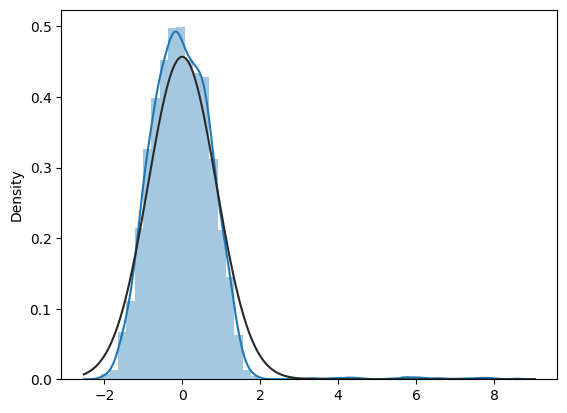

In [189]:
sns.distplot(model.resid, fit=stats.norm)

Основная часть остатков близка к нормальному распределению

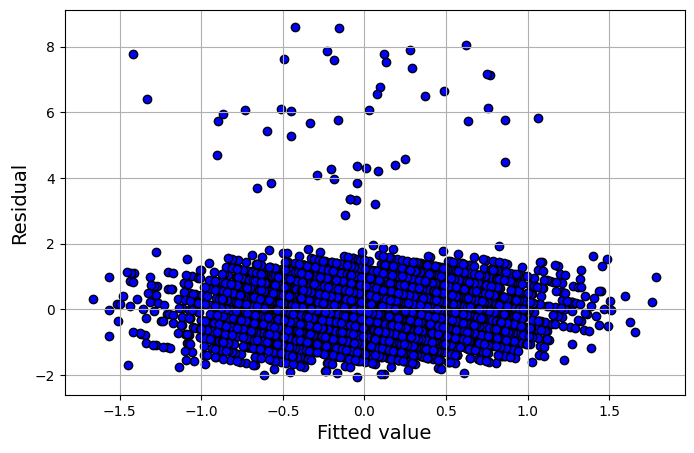

In [190]:
plt.figure(figsize=(8,5))
plt.scatter(x=model.fittedvalues, y=model.resid, color='blue', edgecolor='k')
plt.grid(True)
plt.xlabel('Fitted value', fontsize=14)
plt.ylabel('Residual', fontsize=14)
plt.show()

На графике гетероскедастичность: диапазон остатков изменяется в зависимости от уровня предсказанного значения. Также присутствуют отдельные крупные выбросы, что указывает на наблюдения, плохо объясняемые моделью

In [191]:
outliers = model.resid[abs(model.resid) > 3]
len(outliers)

49

49 - число выбросов и влияющих наблюдений

# 5. Сформулируйте общие содержательные выводы по результатам регрессионного анализа данных. Какие результаты анализа данных для вас оказались очевидными, а какие неожиданными?

Пол оказался невлияющим на оценку ребенка, что в целом ожидаемо. Но неожиданным стал тот факт, что тип школы не влияет на оценку, я считал, что дети в частных школах учатся лучше.

Самым вляительным фактором оказалось время, которое ребенок тратит на учебу. Я считал, что оценка за предыдущий экзамен будет важнее

Физическая активность и обраование родителей значимы, но имеют не сильное влияние, что логично

Модель имеет R^2 = 0.23, что не очень хороший показатель, но это было ожидаемо, так как было выбрано слишком мало признаков, и сама модель довольно простая, она может не учитывать какие-то сложные взаимосвязи

# ДОПОЛНИТЕЛЬНАЯ РАБОТА

Обучим модель градиентного бустинга на всех признаках и оценим ее на метриках

In [192]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import GradientBoostingRegressor

In [193]:
df = pd.read_csv('StudentPerformanceFactors.csv')
X = df.drop(columns=["Exam_score", "Exam_Score"], errors='ignore')
y = df["Exam_Score"]
cat_cols = X.select_dtypes(include=['object']).columns
num_cols = X.select_dtypes(include=['int64', 'float64']).columns


In [194]:
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols),
        ('num', 'passthrough', num_cols)
    ]
)

In [195]:
gbr = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    random_state=42
)

In [196]:
model = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('gbr', gbr)
])

In [197]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [198]:
model.fit(X_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['Parental_Involvement', 'Access_to_Resources',
       'Extracurricular_Activities', 'Motivation_Level', 'Internet_Access',
       'Family_Income', 'Teacher_Quality', 'School_Type', 'Peer_Influence',
       'Learning_Disabilities', 'Parental_Education_Level',
       'Distance_from_Home', 'Gender'],
      dtype='object')),
                                                 ('num', 'passthrough',
                                                  Index(['Hours_Studied', 'Attendance', 'Sleep_Hours', 'Previous_Scores',
       'Tutoring_Sessions', 'Physical_Activity'],
      dtype='object'))])),
                ('gbr',
                 GradientBoostingRegressor(learning_rate=0.05, max_depth=4,
                                           n_estimators=300,
                                           random_state=42))])

In [199]:
y_pred = model.predict(X_test)

In [200]:
mse = mean_squared_error(y_test, y_pred)
rmse = mse**0.5
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MSE:", mse)
print("RMSE:", rmse)
print("MAE:", mae)
print("R²:", r2)

MSE: 3.798643436176273
RMSE: 1.9490108866233335
MAE: 0.7246893009535051
R²: 0.7312611277078886


Например, наша новая модель работает намного лучше, чем, обученная до этого, линейная регрессия, так как R^2 = 0.73, а было 0.23, что, конечно, ожидаемо, так как мы учитываем все признаки, а так же, модель сама по себе более сложная и учитывает более сложные зависимости

Откуда узнал про градиентный бустинг -> https://education.yandex.ru/handbook/ml/article/gradientnyj-busting

**Комментарии к заданию и принципам его оценивания:**

 - Все пункты задания должны сопровождаться выполненным фрагментом кода. В этом задании будет проверяться корректность работы кода, то есть будут последовательно запущены ячейки, чтобы убедиться, что код не выдаст ошибку в какой-то момент. Перед отправкой работы на проверку рекомендуется "прогнать" код.
 - Если Вы получили результаты в виде статистических показателей, таблиц или графиков, при этом никак их не прокомментировали и не сформулировали содержательные выводы на их основе, то работа оценивается в 0 баллов, в этом случае анализ данных не проведён.
 - Если Вы полностью выполнили это задание, то получаете за него 8 баллов (отлично). Для получения более высокой оценки нужно выйти за рамки предложенного задания. В случае с текущим заданием это может быть дополнительное самостоятельное изучение инструментов регрессионного анализа и их применение, или развернутое и глубокое исследование имеющихся данных на основе использования пройденных на занятиях методов.
 - В этом задании 5 пунктов. Первый весит 15%, второй - 20%, третий - 40%, четвертый - 20%, пятый - 5%.
 - Задание можно выполнять индивидуально или в группе из 2 человек, критерии оценивания при этом не меняются.
 - Если задание выполняется вдвоем, то в Smart LMS работу загружает только один из студентов.
 - В названии загружаемого в Smart LMS файла нужно указать фамилию(ии) автора(ов) работы.

### Этот файл нужно сохранить как Jupyter Notebook (.ipynb) и загрузить в Smart LMS до 23:55 18 ноября.

- При сдаче работы до 23:55 19 ноября вычитается 1 балл из итоговой оценки.
- При сдаче работы до 23:55 20 ноября вычитаются 2 балла из итоговой оценки.
- После **23:55 20 ноября** работа не принимается.